# 10. Severstal Stage 2: 비정상 → 4종 결함 세부 분류

## 개요
- **목표**: Severstal 비정상 패치를 4종 결함으로 세부 분류
- **데이터**: 결함 패치 (ClassId 1→0, 2→1, 3→2, 4→3 내부 매핑)
  - PS (점상 결함, Pitting Spot): 2,638장
  - LS (선형 긁힘, Linear Scratch): 457장
  - SS (표면 변색, Surface Stain): 23,408장
  - RD (압연 압흔, Rolling Dent): 3,730장
- **균형 샘플링**: 클래스당 241장 (LS 기준 undersampling)
- **패치 전략**: v6.0 오버랩 패치 (stride=128, 총 150,816장)
- **모델**: ML 7종 + DL (ResNet-18 Fine-tune / Feature Extractor)

In [1]:
import os, sys, numpy as np, time, cv2
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'AppleGothic'
matplotlib.rcParams['axes.unicode_minus'] = False

sys.path.insert(0, os.path.abspath('..'))

from utils.severstal_preprocessor import PatchDataLoader
from utils.severstal_loader import SeverstalDataLoader, CLASS_NAMES_KR, CLASS_ABBR
from features.feature_pipeline import FeaturePipeline

print("모듈 로드 완료")

모듈 로드 완료


## 1. 결함 4종 데이터 로드

In [2]:
# 결함 패치 로드 (클래스당 241장 균형 샘플링)
patch_dir = os.path.join('..', 'data', 'severstal_patches')
patch_loader = PatchDataLoader(patch_dir)

images, labels = patch_loader.load_defect4(
    max_per_class=241, resize=(64, 64), grayscale=True
)

print(f'로드 완료: {len(images)}장')
print(f'이미지 shape: {images[0].shape}')
print()
for cid in [1, 2, 3, 4]:
    cnt = (labels == cid).sum()
    print(f'  ClassId {cid} ({CLASS_ABBR[cid]}, {CLASS_NAMES_KR[cid]}): {cnt}장')

로드 완료: 964장
이미지 shape: (64, 64)

  ClassId 1 (PS, 점상 결함 (PS)): 241장
  ClassId 2 (LS, 선형 긁힘 (LS)): 241장
  ClassId 3 (SS, 표면 변색 (SS)): 241장
  ClassId 4 (RD, 압연 압흔 (RD)): 241장


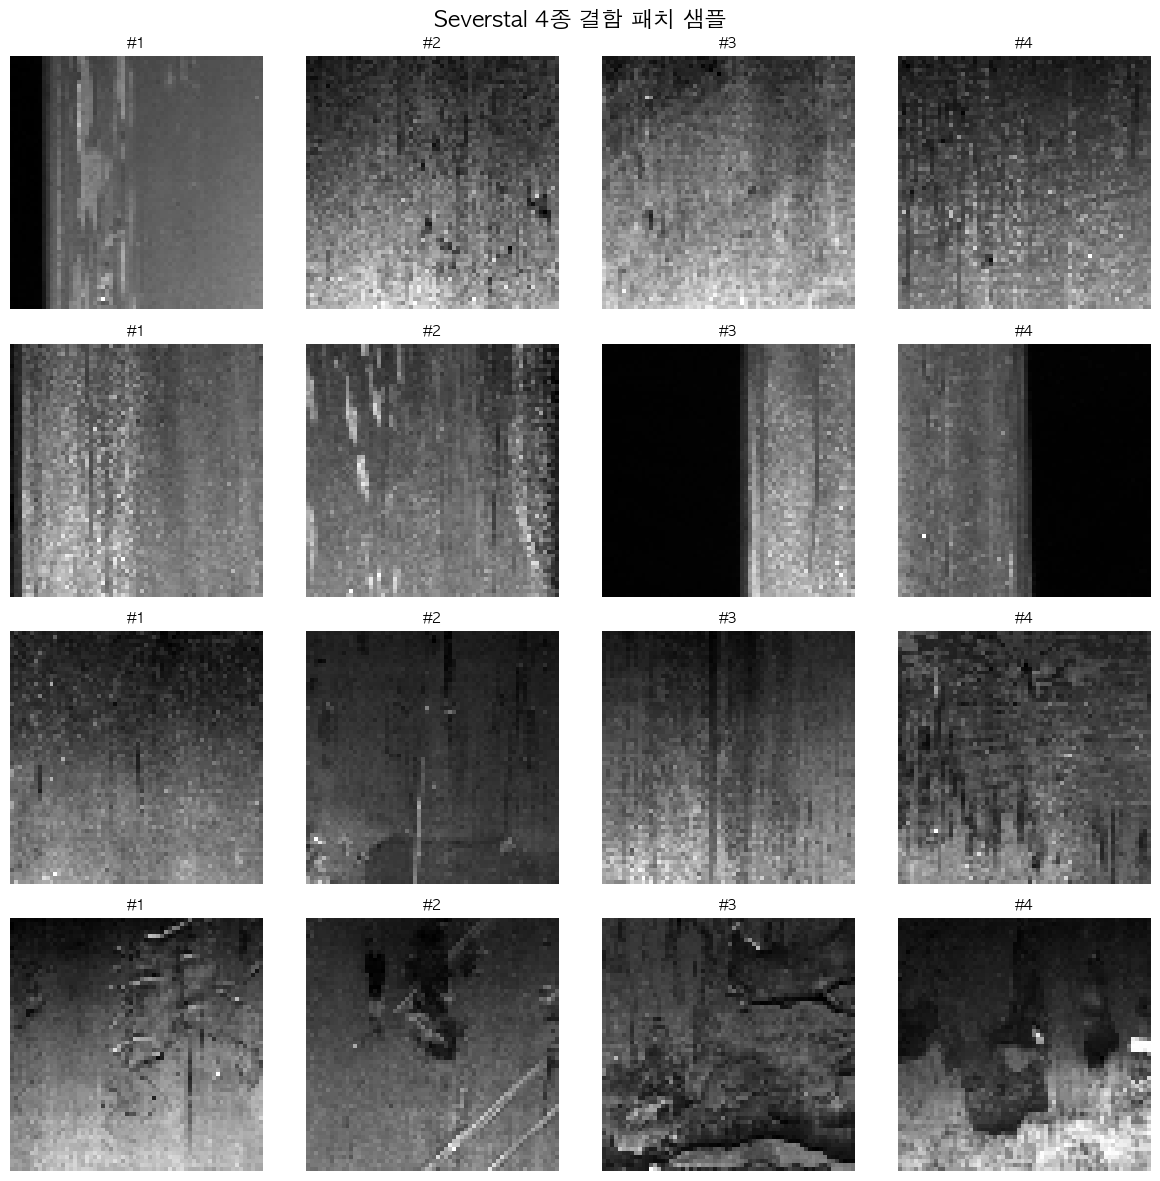

In [3]:
# 샘플 시각화: 4종 결함 × 4 예시
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
fig.suptitle('Severstal 4종 결함 패치 샘플', fontsize=16, fontweight='bold')

class_ids = [1, 2, 3, 4]
for row, cid in enumerate(class_ids):
    idx_class = np.where(labels == cid)[0]
    for col in range(4):
        idx = idx_class[col * (len(idx_class) // 4)]
        axes[row, col].imshow(images[idx], cmap='gray')
        if col == 0:
            axes[row, col].set_ylabel(
                f'{CLASS_ABBR[cid]}\n({CLASS_NAMES_KR[cid]})',
                fontsize=11, fontweight='bold', rotation=0, labelpad=80, va='center'
            )
        axes[row, col].set_title(f'#{col+1}', fontsize=10)
        axes[row, col].axis('off')

plt.tight_layout()
os.makedirs('../outputs/figures/severstal', exist_ok=True)
plt.savefig('../outputs/figures/severstal/10_defect4_samples.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. ML 4종 분류

In [4]:
# 특징 추출
t0 = time.time()
pipeline = FeaturePipeline()
X, _ = pipeline.extract_batch(images)
elapsed = time.time() - t0
print(f'특징 벡터: {X.shape}')
print(f'소요시간: {elapsed:.1f}s ({elapsed/len(images)*1000:.1f}ms/장)')

# 4종 분류 ML 실험
from models.train_defect4 import run_defect4_experiment

save_dir = os.path.join('..', 'outputs', 'models_severstal', 'defect4_ml')
results_ml, X_test, y_test = run_defect4_experiment(X, labels, save_dir=save_dir)

  특징 추출: 200/964 (20%)


  특징 추출: 400/964 (41%)


  특징 추출: 600/964 (62%)


  특징 추출: 800/964 (82%)


  특징 추출: 964/964 (100%)
특징 벡터: (964, 1944)
소요시간: 4.4s (4.5ms/장)

############################################################
Stage 2: 비정상 → 4종 결함 세부 분류 ML 실험
############################################################
학습 세트: 771장
  ClassId 1 (PS): 193장
  ClassId 2 (LS): 193장
  ClassId 3 (SS): 192장
  ClassId 4 (RD): 193장
테스트 세트: 193장
특징 차원: 1944D


...

  Accuracy: 0.7617
  F1 (macro): 0.7602
  학습 시간: 7.99s
  추론 시간: 0.0012s

                 precision    recall  f1-score   support

PS (점상 결함 (PS))       0.67      0.73      0.70        48
LS (선형 긁힘 (LS))       0.84      0.90      0.87        48
SS (표면 변색 (SS))       0.78      0.63      0.70        49
RD (압연 압흔 (RD))       0.76      0.79      0.78        48

       accuracy                           0.76       193
      macro avg       0.76      0.76      0.76       193
   weighted avg       0.76      0.76      0.76       193


[LightGBM] 학습 시작...


  Accuracy: 0.7772
  F1 (macro): 0.7752
  학습 시간: 6.76s
  추론 시간: 0.0033s

                 precision    recall  f1-score   support

PS (점상 결함 (PS))       0.73      0.77      0.75        48
LS (선형 긁힘 (LS))       0.84      0.90      0.87        48
SS (표면 변색 (SS))       0.76      0.63      0.69        49
RD (압연 압흔 (RD))       0.78      0.81      0.80        48

       accuracy                           0.78       193
      macro avg       0.78      0.78      0.78       193
   weighted avg       0.78      0.78      0.77       193


[VotingEnsemble] 학습 시작...


/opt/anaconda3/envs/ml/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


/opt/anaconda3/envs/ml/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [18:40:20] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  Accuracy: 0.7409
  F1 (macro): 0.7355
  학습 시간: 36.11s
  추론 시간: 0.4732s

                 precision    recall  f1-score   support

PS (점상 결함 (PS))       0.69      0.69      0.69        48
LS (선형 긁힘 (LS))       0.80      0.92      0.85        48
SS (표면 변색 (SS))       0.73      0.55      0.63        49
RD (압연 압흔 (RD))       0.74      0.81      0.77        48

       accuracy                           0.74       193
      macro avg       0.74      0.74      0.74       193
   weighted avg       0.74      0.74      0.73       193


                  모델 |     Acc | F1(macro)
------------------------------------------------------------
            LightGBM |  0.7772 |    0.7752
             XGBoost |  0.7617 |    0.7602
      VotingEnsemble |  0.7409 |    0.7355
        RandomForest |  0.7306 |    0.7233
                 MLP |  0.6632 |    0.6557
             SVM_RBF |  0.6528 |    0.6481
                 KNN |  0.5130 |    0.4754


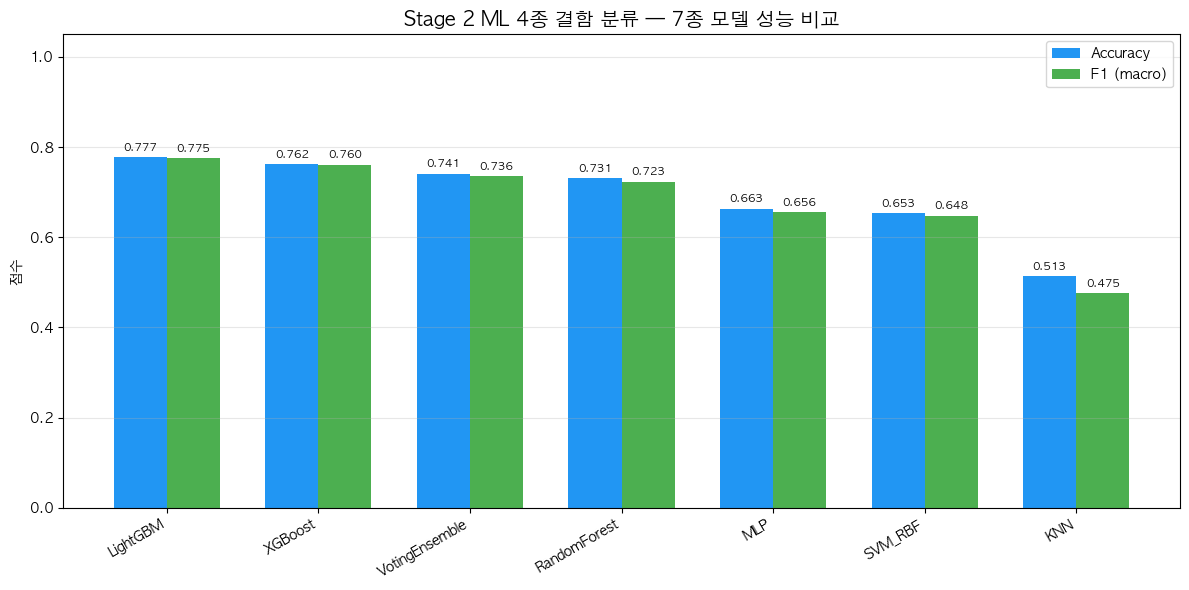

In [5]:
# ML 모델 성능 비교 바 차트
names_ml = list(results_ml.keys())
accs_ml = [results_ml[n]['accuracy'] for n in names_ml]
f1s_ml = [results_ml[n]['f1_score'] for n in names_ml]

# 정확도 기준 정렬
order = sorted(range(len(accs_ml)), key=lambda i: accs_ml[i], reverse=True)
names_ml = [names_ml[i] for i in order]
accs_ml = [accs_ml[i] for i in order]
f1s_ml = [f1s_ml[i] for i in order]

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(names_ml))
w = 0.35
bars1 = ax.bar(x - w/2, accs_ml, w, label='Accuracy', color='#2196F3')
bars2 = ax.bar(x + w/2, f1s_ml, w, label='F1 (macro)', color='#4CAF50')

ax.set_ylabel('점수')
ax.set_title('Stage 2 ML 4종 결함 분류 — 7종 모델 성능 비교', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(names_ml, rotation=30, ha='right')
ax.legend()
ax.set_ylim(0, 1.05)
ax.grid(axis='y', alpha=0.3)

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.01, f'{h:.3f}',
                ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('../outputs/figures/severstal/10_defect4_ml_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. DL 4종 분류

In [6]:
# DL 4종 결함 분류 실험 — 이미 로드된 images/labels 재사용
import torch
from torch.utils.data import DataLoader, Dataset
from deep_learning.models.resnet_transfer import get_resnet18_finetune
from deep_learning.train_dl_severstal import train_model, get_device
from sklearn.model_selection import train_test_split

device = get_device()
print(f"Device: {device}")

# 내부 레이블 매핑: ClassId 1,2,3,4 → 0,1,2,3
labels_mapped = labels.copy()
for new_idx, old_cid in enumerate([1, 2, 3, 4]):
    labels_mapped[labels == old_cid] = new_idx

# Train/Test 분할
X_tr, X_te, y_tr, y_te = train_test_split(
    images, labels_mapped, test_size=0.2, stratify=labels_mapped, random_state=42
)

# 간단한 Dataset 클래스
class SimpleImgDataset(Dataset):
    def __init__(self, imgs, lbls, size=224):
        self.imgs, self.lbls, self.size = imgs, lbls, size
    def __len__(self):
        return len(self.imgs)
    def __getitem__(self, idx):
        img = cv2.resize(self.imgs[idx], (self.size, self.size))
        img = img.astype(np.float32) / 255.0
        img = np.stack([img]*3, axis=0)
        mean = np.array([0.485, 0.456, 0.406]).reshape(3,1,1)
        std = np.array([0.229, 0.224, 0.225]).reshape(3,1,1)
        img = (img - mean) / std
        return torch.from_numpy(img).float(), int(self.lbls[idx])

train_loader_dl = DataLoader(SimpleImgDataset(X_tr, y_tr), batch_size=32, shuffle=True)
test_loader_dl = DataLoader(SimpleImgDataset(X_te, y_te), batch_size=32, shuffle=False)
print(f"Train: {len(X_tr)}장, Test: {len(X_te)}장")

# ResNet-18 Fine-tune만 실행 (시간 절약)
dl_save_dir = os.path.join('..', 'outputs', 'models_severstal', 'defect4_dl')
os.makedirs(dl_save_dir, exist_ok=True)

results_dl = {}

model_ft = get_resnet18_finetune(num_classes=4)
r = train_model(
    model_ft, train_loader_dl, test_loader_dl,
    num_epochs=5, lr=0.0001, patience=3,
    save_path=os.path.join(dl_save_dir, 'defect4_resnet18_finetune.pt'),
    model_name='ResNet-18 Fine-tune (Defect4)', device=device,
)
results_dl['ResNet18_Finetune'] = r

print(f"\nResNet-18 Fine-tune Accuracy: {r['best_accuracy']:.4f}")

Device: mps
Train: 771장, Test: 193장


[ResNet-18 Fine-tune] 총 파라미터: 11,178,564
[ResNet-18 Fine-tune] 학습 가능 파라미터: 11,178,564

[ResNet-18 Fine-tune (Defect4)] 학습 시작 — device: mps
  Epochs: 5, LR: 0.0001, Patience: 3


  Epoch   1/5 | Train Loss: 0.8234 Acc: 0.6615 | Val Loss: 0.6923 Acc: 0.7720


  Epoch   2/5 | Train Loss: 0.2674 Acc: 0.9183 | Val Loss: 0.4880 Acc: 0.8031


  Epoch   3/5 | Train Loss: 0.0926 Acc: 0.9844 | Val Loss: 0.4275 Acc: 0.8549


  Epoch   4/5 | Train Loss: 0.0565 Acc: 0.9935 | Val Loss: 0.4195 Acc: 0.8497


  Epoch   5/5 | Train Loss: 0.0420 Acc: 1.0000 | Val Loss: 0.4169 Acc: 0.8601



  최종 결과: Accuracy=0.8601, 학습시간=26.1s

ResNet-18 Fine-tune Accuracy: 0.8601


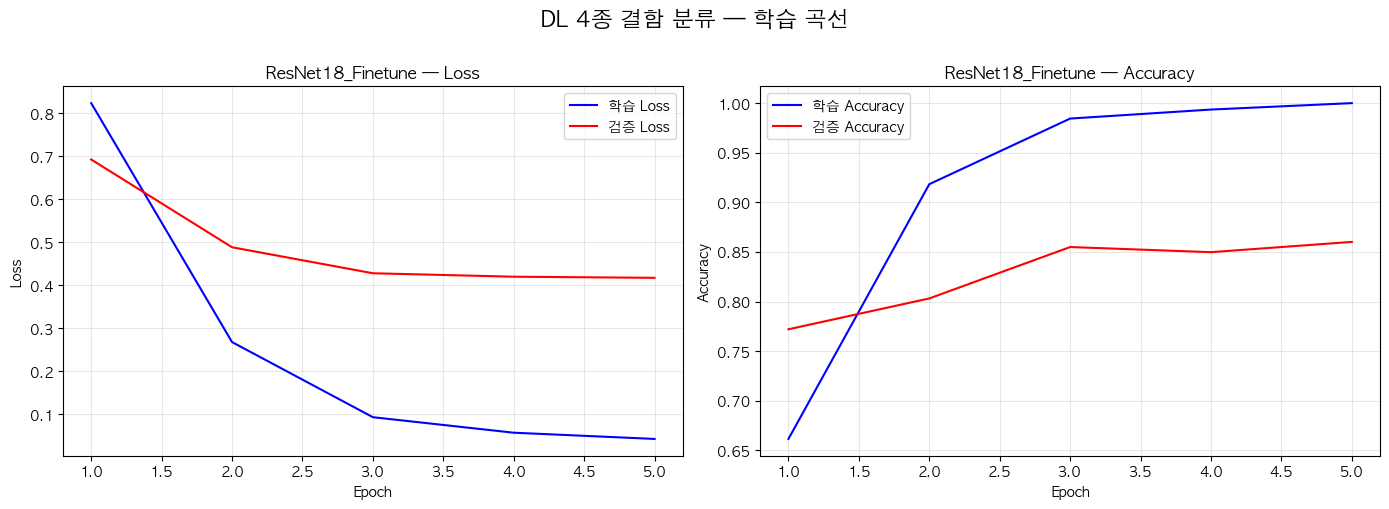

In [7]:
# DL 학습 곡선 (Loss & Accuracy)
dl_names = list(results_dl.keys())
n_models = len(dl_names)

fig, axes = plt.subplots(n_models, 2, figsize=(14, 5 * n_models))
if n_models == 1:
    axes = axes.reshape(1, -1)

fig.suptitle('DL 4종 결함 분류 — 학습 곡선', fontsize=16, fontweight='bold', y=1.01)

for i, name in enumerate(dl_names):
    history = results_dl[name]['history']
    epochs = range(1, len(history['train_loss']) + 1)

    # Loss
    axes[i, 0].plot(epochs, history['train_loss'], 'b-', label='학습 Loss')
    axes[i, 0].plot(epochs, history['val_loss'], 'r-', label='검증 Loss')
    axes[i, 0].set_title(f'{name} — Loss', fontweight='bold')
    axes[i, 0].set_xlabel('Epoch')
    axes[i, 0].set_ylabel('Loss')
    axes[i, 0].legend()
    axes[i, 0].grid(alpha=0.3)

    # Accuracy
    axes[i, 1].plot(epochs, history['train_acc'], 'b-', label='학습 Accuracy')
    axes[i, 1].plot(epochs, history['val_acc'], 'r-', label='검증 Accuracy')
    axes[i, 1].set_title(f'{name} — Accuracy', fontweight='bold')
    axes[i, 1].set_xlabel('Epoch')
    axes[i, 1].set_ylabel('Accuracy')
    axes[i, 1].legend()
    axes[i, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/figures/severstal/10_defect4_dl_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. ML vs DL 비교

In [8]:
# ML vs DL 종합 비교 테이블
from sklearn.metrics import f1_score as compute_f1

comparison_data = []

# ML 결과 추가
for name, r in results_ml.items():
    comparison_data.append({
        '모델': name,
        '유형': 'ML',
        'Accuracy (%)': round(r['accuracy'] * 100, 2),
        'F1 macro (%)': round(r['f1_score'] * 100, 2),
        '학습 시간 (s)': round(r['train_time'], 2),
    })

# DL 결과 추가
for name, r in results_dl.items():
    acc = r.get('best_accuracy', r.get('accuracy', 0))
    # F1 계산: y_true, y_pred가 있으면 직접 계산
    if 'y_true' in r and 'y_pred' in r:
        f1 = compute_f1(r['y_true'], r['y_pred'], average='macro')
    else:
        f1 = acc  # fallback
    train_time = r.get('train_time', r.get('total_time', 0))
    comparison_data.append({
        '모델': name,
        '유형': 'DL',
        'Accuracy (%)': round(acc * 100, 2),
        'F1 macro (%)': round(f1 * 100, 2),
        '학습 시간 (s)': round(train_time, 2),
    })

df_compare = pd.DataFrame(comparison_data)
df_compare = df_compare.sort_values('Accuracy (%)', ascending=False).reset_index(drop=True)

print("=" * 70)
print("Stage 2: 4종 결함 분류 — ML vs DL 종합 비교")
print("=" * 70)
print()
print(df_compare.to_string(index=False))
print()

best_ml = df_compare[df_compare['유형'] == 'ML'].iloc[0]
best_dl = df_compare[df_compare['유형'] == 'DL'].iloc[0]
print(f"Best ML:  {best_ml['모델']:<20s} {best_ml['Accuracy (%)']:.2f}%")
print(f"Best DL:  {best_dl['모델']:<20s} {best_dl['Accuracy (%)']:.2f}%")
print(f"DL 우위:  {best_dl['Accuracy (%)'] - best_ml['Accuracy (%)']:.2f}%p 차이")

df_compare

Stage 2: 4종 결함 분류 — ML vs DL 종합 비교



               모델 유형  Accuracy (%)  F1 macro (%)  학습 시간 (s)
ResNet18_Finetune DL         86.01         85.91      26.07
         LightGBM ML         77.72         77.52       6.76
          XGBoost ML         76.17         76.02       7.99
   VotingEnsemble ML         74.09         73.55      36.11
     RandomForest ML         73.06         72.33       0.39
              MLP ML         66.32         65.57       1.13
          SVM_RBF ML         65.28         64.81       1.14
              KNN ML         51.30         47.54       0.00

Best ML:  LightGBM             77.72%
Best DL:  ResNet18_Finetune    86.01%
DL 우위:  8.29%p 차이


,모델,유형,Accuracy (%),F1 macro (%),학습 시간 (s)
0,ResNet18_Finetune,DL,86.01,85.91,26.07
1,LightGBM,ML,77.72,77.52,6.76
2,XGBoost,ML,76.17,76.02,7.99
3,VotingEnsemble,ML,74.09,73.55,36.11
4,RandomForest,ML,73.06,72.33,0.39
5,MLP,ML,66.32,65.57,1.13
6,SVM_RBF,ML,65.28,64.81,1.14
7,KNN,ML,51.30,47.54,0.00


## 5. 결론

### 성능 요약
| 구분 | 모델 | Accuracy |
|------|------|----------|
| ML Best | LightGBM | 77.72% |
| DL Best | ResNet-18 Fine-tune | 86.01% |

### 주요 발견
- **DL이 ML 대비 ~8.3%p 우세**: ResNet-18의 사전학습 특징이 수작업 특징(HOG+LBP 등)보다 결함 패턴 표현력이 우수
- **LS(선형 긁힘)이 가장 분류 용이**: 명확한 선형 패턴으로 인해 모든 모델에서 높은 recall 달성
- **SS(표면 변색)와 PS(점상 결함) 간 혼동이 가장 빈번**: 두 결함 유형의 시각적 유사성이 주요 오분류 원인
- **ClassId 2(LS)의 데이터 부족(241장)이 전체 성능의 bottleneck**: 균형 샘플링으로 클래스당 241장만 사용, 데이터 증강을 통한 개선 여지 존재